# 02. Neural Network Classification with Tensorflow

**Neural Networks for Classification**

Classification is a supervised learning task where the goal is to assign input data to one or more predefined categories (classes). Neural networks excel at this because they can handle high-dimensional data like images, text, or audio.

- **How It Works:** The output layer typically uses a softmax activation function to convert raw scores into probabilities that sum to 1 (e.g., 80% chance it's a cat, 20% a dog). During training, the network is fed labeled data (e.g., images tagged as "cat" or "dog") and learns to map inputs to correct classes.

- **Neural Network with Classification**
    
    When a neural network is used to classify things, it’s called a neural network for classification.
        
    Here’s how it works:
        
    1. **Input data:** You feed the network some data (like an image of a cat).
    2. **Processing:** The hidden layers learn patterns from the data (like edges, shapes).
    3. **Output layer:** Instead of one number, it gives you probabilities for each class.

    - **Example: Image Classification**
    
        Imagine classifying handwritten digits (like in the MNIST dataset).
      
        A simple feedforward neural network might achieve 95%+ accuracy after training.
    
        - Input: A 28x28 pixel grayscale image flattened into 784 values.
        - Hidden Layers: Process features like edges or curves.
        - Output: 10 neurons, one for each digit (0-9). The neuron with the highest probability wins.

- **Types of Neural Networks for Classification:**

    - **Feedforward Neural Networks (MLPs):** Basic for tabular data (e.g., predicting email spam: yes/no).
    - **Convolutional Neural Networks (CNNs):** Great for images/videos (e.g., identifying objects in photos).
    - **Recurrent Neural Networks (RNNs/LSTMs):** For sequential data like text sentiment analysis.

**Common Use Cases**

- Handwriting recognition
- Email spam detection
- Image classification
- Voice recognition
- Medical diagnosis

### Architecture of a Classification Neural Network

**Quick Example:**

- Binary: Is this tumor malignant (1) or benign (0)?
- Multiclass: What digit is in this image? (0–9)

| **Component**         | **Binary Classification**                                             | **Multiclass Classification**                                         |
| --------------------- | --------------------------------------------------------------------- | --------------------------------------------------------------------- |
| **Input Layer**       | Typically a vector of features (e.g., shape `(batch_size, features)`) | Typically a vector of features (e.g., shape `(batch_size, features)`) |
| **Input Activation**  | No activation (raw input)                                             | No activation (raw input)                                             |
| **Hidden Layers**     | Dense layers with ReLU activation (or other activation functions)     | Dense layers with ReLU activation (or other activation functions)     |
| **Output Layer Size** | 1 neuron (for binary class prediction)                                | Number of neurons = number of classes (e.g., 3 neurons for 3 classes) |
| **Output Activation** | **Sigmoid** (outputs probability for class 1)                         | **Softmax** (outputs probabilities for each class)                    |
| **Output Range**      | 0 to 1 (probability of class 1)                                       | Each output: 0 to 1; All outputs sum to 1                             |
| **Loss Function**     | **Binary Cross-Entropy** (`binary_crossentropy`)                      | **Categorical Cross-Entropy** (`categorical_crossentropy`)            |
| **Label Format (y)**  | Single value: 0 or 1                                                  | One-hot encoded vector (e.g., [0,1,0]) or class index                 |
| **Optimizer**         | **Adam** (`adam`), **SGD** (`sgd`) or **RMSprop** (`rmsprop`)         | **Adam** (`adam`), **SGD** (`sgd`), or **RMSprop** (`rmsprop`)        |
| **Use Case Examples** | Spam vs. Not Spam, Disease vs. No Disease                             | Dog vs. Cat vs. Bird, Digit classification (0–9), Sentiment analysis  |


In [17]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
tf.__version__

'2.19.1'

### Data Viewing and Fitting

In [3]:
from sklearn.datasets import make_circles

In [4]:
# make 1000 examples
n_samples = 1000

# create circles
X, y = make_circles(n_samples,
                   noise=0.03,
                   random_state=42)

In [5]:
# view the 1st 3 data
X[:3], y[:3]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203]]),
 array([1, 1, 1]))

### Visualize the Data

In [6]:
circles = pd.DataFrame({
    "X0": X[:, 0], "X1": X[:, 1], "label": y
})

In [7]:
# check the 1st 3 data
circles.head(3)

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1


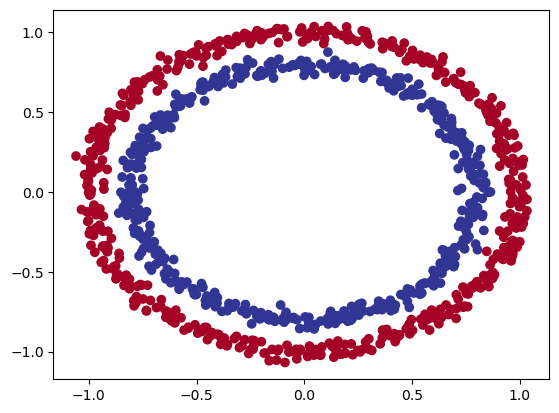

In [8]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

### Input and Output Shapes

In [9]:
# check the shapes of our features and labels
X.shape, y.shape

((1000, 2), (1000,))

In [10]:
# how many samples we're working
len(X), len(y)

(1000, 1000)

In [11]:
# view the first example of features and labels
X[0], y[0]

(array([0.75424625, 0.23148074]), 1)

### Building a Model

In [95]:
tf.random.set_seed(42)

# create the model with sequential
model = tf.keras.Sequential([
    tf.keras.layers.Dense(500, activation="relu"),
    tf.keras.layers.Dense(250, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# compile the model
model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
             optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
             metrics=["accuracy"])

# fit the model
history = model.fit(X, y, epochs=10)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5367 - loss: 0.6938   
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7746 - loss: 0.5232 
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9578 - loss: 0.1826 
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9759 - loss: 0.0687 
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9796 - loss: 0.0487 
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9737 - loss: 0.0651 
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9213 - loss: 0.2370 
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9943 - loss: 0.0288 
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9975 - loss: 0.0144 
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9990 - loss: 0.0073 


In [96]:
model.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0056  


[0.005552588030695915, 1.0]

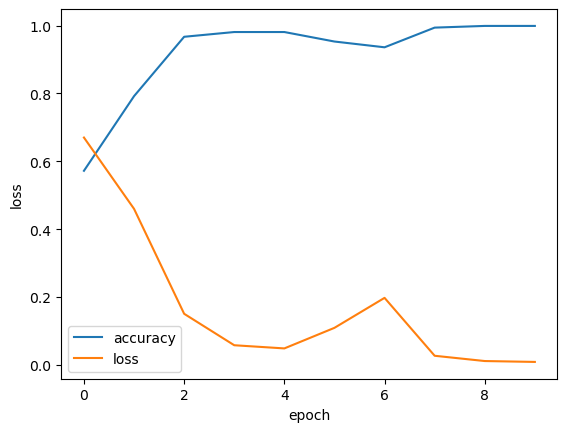

In [97]:
pd.DataFrame(history.history).plot()
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend()

In [98]:
def plot_decision_bounday(model, X, y):
    """
    Plot the decision boundary created by a model predicting on X
    """

    # define the axis boundaries of the plot and create a meshgrid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                        np.linspace(y_min, y_max, 100))

    # create X value (we're going to make predictions on these)
    x_in = np.c_[xx.ravel(), yy.ravel()] # stack 2D arrays together

    # make predictions
    y_pred = model.predict(x_in)

    # check for multi-class
    if len(y_pred[0]) > 1:
        print("Doing multiclass classification")
        y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
    else:
        print("Binary classification")
        y_pred = np.round(y_pred).reshape(xx.shape)

    # plot the decision boundary
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 951us/step
Binary classification


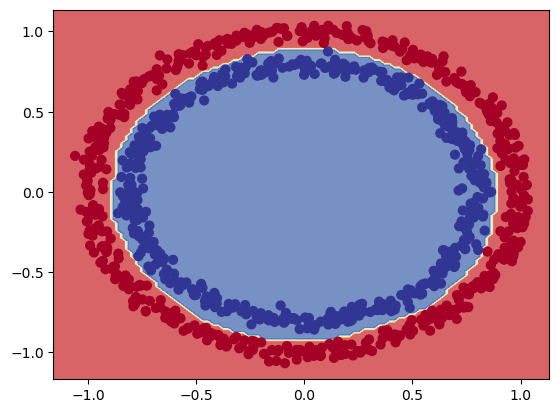

In [99]:
plot_decision_bounday(model, X, y)

### What is Sigmoid Function?

- **Sigmoid** squashes input to the range (0, 1).
- Perfect for **binary classification output layers**.
- Built-in in TensorFlow via `tf.nn.sigmoid()` or `activation='sigmoid'` in Keras layers.
- Avoid in **hidden** layers due to **vanishing gradients**.
- Still widely used in logistic **regression, binary classifiers,** and **probability** output models.

**Mathematical Definition**

The sigmoid function, often denoted as σ(x) or simply "sigmoid," transforms any real-valued input $ x \in (-\infty, \infty) $ into a bounded output in the range (0, 1). Its formula is:

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

- Here, $ e $ is the base of the natural logarithm (approximately 2.71828).
- For large positive $ x $ (e.g., $ x > 10 $), $ e^{-x} $ approaches 0, so σ(x) ≈ 1.
- For large negative $ x $ (e.g., $ x < -10 $), $ e^{-x} $ approaches ∞, so σ(x) ≈ 0.
- At $ x = 0 $, σ(0) = 0.5, acting as a midpoint.

This creates an **S-shaped (sigmoidal) curve**, which mimics the firing behavior of biological neurons (firing more aggressively as input increases but saturating at extremes).

The function is **continuously differentiable**, which is crucial for gradient-based optimization in training neural networks via backpropagation.

In [103]:
x_sigmoid = tf.cast(tf.range(-10, 10), tf.float32)

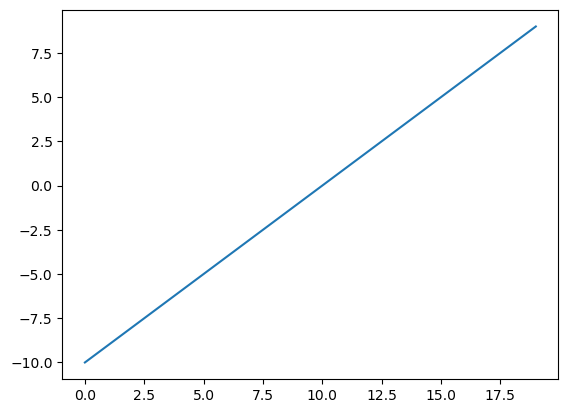

In [106]:
plt.plot(x_sigmoid)

In [104]:
def sigmoid(X):
    return 1 / (1 + tf.exp(-X))

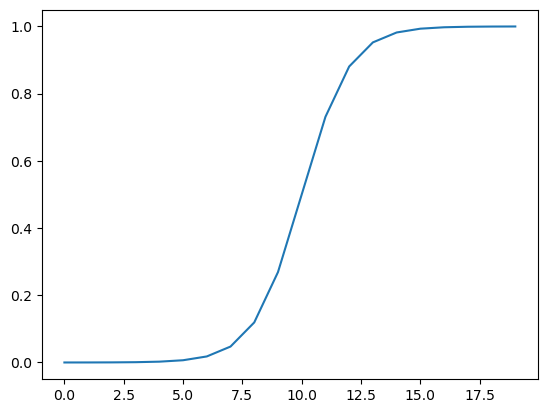

In [105]:
plt.plot(sigmoid(x_sigmoid))

### What is ReLu?

**ReLU** stands for **Rectified Linear Unit**.

It's a simple, fast, and highly effective **non-linear** activation function used in the **hidden layers** of neural networks.

The **Rectified Linear Unit (ReLU)** is a cornerstone activation function in modern deep learning, prized for its simplicity and efficiency. Introduced in the early 2010s (notably in the 2010 paper "ImageNet Classification with Deep Convolutional Neural Networks" by Alex Krizhevsky et al.), ReLU has become the `default choice for hidden layers in most neural networks due to its ability to mitigate key training issues like vanishing gradients`. In TensorFlow, ReLU is natively supported and optimized for high-performance computing on CPUs, GPUs, and TPUs, making it a go-to for scalable models.

**Mathematical Definition**

ReLU is a piecewise linear function that outputs the input directly if it's positive and zero otherwise. Its formula is straightforward:

$$f(x) = \max(0, x)$$

- For $ x > 0 $, $ f(x) = x $ (linear pass-through).
- For $ x \leq 0 $, $ f(x) = 0 $ (rectification, "turning off" the neuron).
- It's not differentiable at exactly $ x = 0 $, but in practice, we define the subgradient there as 0 or 1 (commonly 0 for simplicity in implementations).

This "half-line" shape is why it's called "rectified"—it rectifies negative values to zero, mimicking a diode in electronics.

**Usage in TensorFlow**

TensorFlow integrates ReLU via `tf.nn` for low-level ops and Keras for high-level models. It's element-wise on tensors and supports autodiff.

- **Low-Level:** `tf.nn.relu(x)` or `tf.nn.relu6(x)` (caps at 6 for stability).
- **High-Level: Keras**
    - `tf.keras.layers.Activation('relu')`
    - In `tf.keras.layers.Dense(..., activation='relu')`
    - `tf.keras.activations.relu(x)`

In [107]:
def ReLu(x):
    return tf.maximum(0, x)

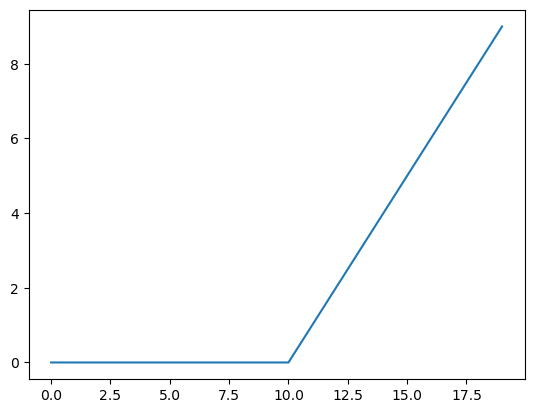

In [110]:
plt.plot(ReLu(x_sigmoid))